In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [14]:
df = pd.read_csv("../Data/train.csv")


In [15]:
drop_cols = ['lyrics', 'track_name', 'artist_name', 'release_date']
df.drop(columns=drop_cols, inplace=True, errors='ignore')


In [16]:
df.dropna(inplace=True)


In [17]:
df.drop(columns=['genre', 'topic'], inplace=True, errors='ignore')


In [18]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df.select_dtypes(include='number'))


In [19]:
pca = PCA(n_components=0.95)
pca_data = pca.fit_transform(scaled)


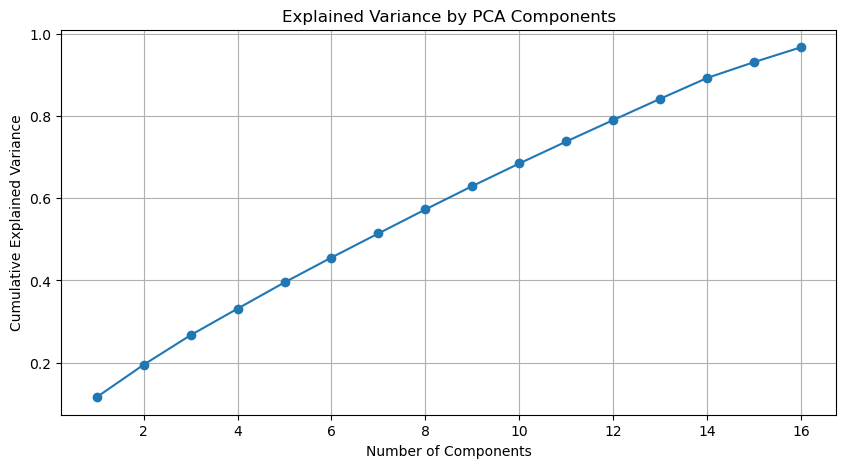

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()


In [22]:
os.makedirs("Data", exist_ok=True)  # create directory if it doesn't exist
pca_df = pd.DataFrame(pca_data)
pca_df.to_csv("../Data/clean_data.csv", index=False)